# Laboratorio 4 — Parte 2: modelos de Machine Learning sobre datos geoespaciales
## Lagos Atitlán y Amatitlán — Ejercicios 1 a 10 (entrega completa)

Este notebook continúa el trabajo de `Lab4.ipynb` (Parte I). A partir de los mismos rasters Sentinel-2 L2A (mismos lagos, mismas 11 fechas oficiales por lago), se construye un **conjunto de datos tabular** apto para Machine Learning, se define la **variable respuesta binaria** de alta presencia de cianobacteria, y se seleccionan/justifican las **variables predictoras**.

**Alcance:** los 10 ejercicios de la guía `Laboratorio_4_Parte_2_Datos_Geoespaciales_2026.md` — preparación de datos, variable respuesta, selección de predictores, modelos (Regresión Logística, Random Forest, Gradient Boosting/XGBoost), evaluación, validación espacial y temporal, generalización entre lagos, interpretabilidad (SHAP) y mapas predictivos.


## 0. Dependencias y configuración

Se reutilizan las mismas dependencias de la Parte I. Si el caché de escenas (`data/GIS/lab4_avance/*.tif`) generado en la Parte I ya existe en este equipo, se reutiliza directamente; en caso contrario, se descarga de nuevo desde openEO (requiere autenticación OIDC con cuenta Copernicus).

In [96]:
from datetime import date, timedelta
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import openeo
import pandas as pd
import rasterio
from rasterio.warp import transform as warp_transform

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", 30)

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data" / "GIS" / "lab4_avance"       # cache de escenas de la Parte I (se reutiliza)
OUT_DIR = BASE_DIR / "data" / "GIS" / "lab4_parte2"          # salidas propias de esta Parte II
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

API_URL = "https://openeo.dataspace.copernicus.eu"
COLLECTION = "SENTINEL2_L2A"
BANDS = ["B02", "B03", "B04", "B05", "B08", "SCL"]

# Paso del muestreo sistemático (en píxeles nativos, ~10 m/píxel). Ver justificación en el Ejercicio 1.6.
SAMPLE_STRIDE_PX = 20

print(f"Cache de escenas (Parte I): {DATA_DIR.resolve()}")
print(f"Salidas de esta Parte II: {OUT_DIR.resolve()}")

Cache de escenas (Parte I): /Users/dijan/Documents/U/Data Science/Lab4/data/GIS/lab4_avance
Salidas de esta Parte II: /Users/dijan/Documents/U/Data Science/Lab4/data/GIS/lab4_parte2


## 1. Áreas y fechas oficiales (idénticas a la Parte I)

La guía de la Parte II exige usar las mismas fechas que en la Parte I. Se copian exactamente los mismos diccionarios `LAKES` y `OFFICIAL_DATES` de `Lab4.ipynb`.

In [97]:
LAKES = {
    "Atitlan": {
        "west": -91.326256, "east": -91.07151,
        "south": 14.5948, "north": 14.750979,
    },
    "Amatitlan": {
        "west": -90.638065, "east": -90.512924,
        "south": 14.412347, "north": 14.493799,
    },
}

OFFICIAL_DATES = {
    "Atitlan": [
        "2025-01-18", "2025-04-13", "2025-05-13",
        "2025-07-17", "2025-11-21", "2025-12-29",
        "2026-02-12", "2026-03-24", "2026-04-13",
        "2026-04-28", "2026-07-22",
    ],
    "Amatitlan": [
        "2025-01-28", "2025-04-15", "2025-04-28",
        "2025-11-24", "2026-01-08", "2026-02-02",
        "2026-02-07", "2026-03-29", "2026-04-13",
        "2026-04-28", "2026-06-19",
    ],
}

assert set(LAKES) == set(OFFICIAL_DATES)
assert all(len(v) == 11 for v in OFFICIAL_DATES.values())
print("Configuración validada: 2 lagos y 11 fechas oficiales por lago (idénticas a la Parte I).")

Configuración validada: 2 lagos y 11 fechas oficiales por lago (idénticas a la Parte I).


## Ejercicio 1. Preparación de los datos para Machine Learning

### 1.1–1.3 Descarga (o reutilización de caché), lectura de rasters y construcción del conjunto tabular

Cada escena Sentinel-2 se convierte en una tabla de píxeles, aplicando tres filtros antes de aceptar una observación:

1. **Máscara de nubes/nodata (SCL):** se descartan píxeles con `SCL` en {0 nodata, 1 saturado, 3 sombra, 8-10 nubes, 11 nieve/hielo} — igual que en la Parte I.
2. **Máscara de agua (NDWI):** en la Parte I no se encontró un polígono oficial de los lagos en el repositorio, por lo que la geometría de trabajo fue el bounding box (que incluye tierra). Para el Ejercicio 1.3 ("elimine observaciones... fuera de los límites del lago") se necesita algo más preciso que el bounding box: se usa `NDWI > 0` como proxy operativo de "superficie de agua" (McFeeters, 1996, *The use of the Normalized Difference Water Index (NDWI) in the delineation of open water features*, IJRS 17(7), 1425-1432), descartando así los píxeles de tierra dentro del bounding box.
3. **Muestreo sistemático espacial:** se conserva únicamente 1 de cada `SAMPLE_STRIDE_PX` filas/columnas de la grilla nativa (~10 m/píxel). Ver justificación completa en el Ejercicio 1.6.

In [98]:
connection = openeo.connect(API_URL)
connection = connection.authenticate_oidc()
print(f"Conexion autenticada: {API_URL}")

Authenticated using refresh token.
Conexion autenticada: https://openeo.dataspace.copernicus.eu


In [99]:
def scene_path(lake_name, date_text):
    return DATA_DIR / f"{lake_name}_{date_text}.tif"

def download_scene(connection, lake_name, date_text):
    target = scene_path(lake_name, date_text)
    if target.exists() and target.stat().st_size > 0:
        return target
    start = date.fromisoformat(date_text)
    end = start + timedelta(days=1)
    cube = connection.load_collection(
        COLLECTION,
        spatial_extent=LAKES[lake_name],
        temporal_extent=[start.isoformat(), end.isoformat()],
        bands=BANDS,
    )
    job = connection.create_job(
        cube.save_result(format="GTIFF"),
        title=f"Lab4_{lake_name}_{date_text}",
    )
    job.start_and_wait()
    job.download_results(str(target))
    if not target.exists():
        raise FileNotFoundError(f"openEO no creo {target}")
    return target

scene_files = []
for lake_name in LAKES:
    for date_text in OFFICIAL_DATES[lake_name]:
        path = download_scene(connection, lake_name, date_text)
        scene_files.append((lake_name, date_text, path))
print(f"Escenas disponibles: {len(scene_files)}")

Escenas disponibles: 22


In [100]:
def safe_normalized_difference(a, b):
    denominator = a + b
    return np.divide(a - b, denominator, out=np.full_like(a, np.nan, dtype=np.float32), where=denominator != 0)

def build_pixel_table(path, lake_name, date_text, stride=SAMPLE_STRIDE_PX):
    with rasterio.open(path) as src:
        raw = src.read()
        transform = src.transform
        crs = src.crs
        descriptions = list(src.descriptions)
    names = [d.upper() if d else BANDS[i] for i, d in enumerate(descriptions)]
    band_map = {name: raw[i] for i, name in enumerate(names)}
    missing = set(BANDS) - set(band_map)
    if missing:
        raise ValueError(f"Faltan bandas {missing} en {path.name}; descripciones={descriptions}")

    # Se acota a [0, 1]: la reflectancia de superficie no puede ser negativa ni mayor a 1;
    # sin este recorte, denominadores cercanos a 0 en (a-b)/(a+b) producen indices fuera de [-1, 1].
    scale = {
        name: np.clip(band_map[name].astype(np.float32) / 10000.0, 0.0, 1.0)
        for name in BANDS if name != "SCL"
    }
    ndvi = safe_normalized_difference(scale["B08"], scale["B04"])
    ndwi = safe_normalized_difference(scale["B03"], scale["B08"])
    ndci = safe_normalized_difference(scale["B05"], scale["B04"])

    scl = band_map["SCL"]
    clear = ~np.isin(scl, [0, 1, 3, 8, 9, 10, 11])
    water = ndwi > 0.0  # proxy de "dentro del lago" ante ausencia de poligono oficial (McFeeters, 1996)
    valid = clear & water & np.isfinite(ndvi) & np.isfinite(ndwi) & np.isfinite(ndci)

    # Muestreo sistematico: solo se conservan filas/columnas multiplo de `stride`.
    grid_mask = np.zeros(valid.shape, dtype=bool)
    grid_mask[::stride, ::stride] = True
    keep_mask = valid & grid_mask
    rows_idx, cols_idx = np.where(keep_mask)
    if rows_idx.size == 0:
        return pd.DataFrame()

    xs, ys = rasterio.transform.xy(transform, rows_idx, cols_idx, offset="center")
    xs, ys = np.array(xs), np.array(ys)
    lon, lat = warp_transform(crs, "EPSG:4326", xs, ys)

    data = {
        "lake": lake_name,
        "date": pd.Timestamp(date_text),
        "row": rows_idx,
        "col": cols_idx,
        "lon": np.array(lon),
        "lat": np.array(lat),
    }
    for b in ["B02", "B03", "B04", "B05", "B08"]:
        data[b] = scale[b][rows_idx, cols_idx]
    data["NDVI"] = ndvi[rows_idx, cols_idx]
    data["NDWI"] = ndwi[rows_idx, cols_idx]
    data["NDCI"] = ndci[rows_idx, cols_idx]
    return pd.DataFrame(data)

print("Verificacion: la funcion reutiliza la misma logica de indices (NDVI/NDWI/NDCI) y mascara de nubes de la Parte I.")

Verificacion: la funcion reutiliza la misma logica de indices (NDVI/NDWI/NDCI) y mascara de nubes de la Parte I.


In [101]:
frames = []
for lake_name, date_text, path in scene_files:
    frame = build_pixel_table(path, lake_name, date_text)
    frames.append(frame)
    print(f"{lake_name} {date_text}: {len(frame):,} observaciones muestreadas")

ml_dataset = pd.concat(frames, ignore_index=True)
ml_dataset.to_csv(OUT_DIR / "ml_dataset_bruto.csv", index=False)
print(f"\nTotal de observaciones: {len(ml_dataset):,}")
ml_dataset.head()

Atitlan 2025-01-18: 1,864 observaciones muestreadas
Atitlan 2025-04-13: 3,076 observaciones muestreadas
Atitlan 2025-05-13: 3,090 observaciones muestreadas
Atitlan 2025-07-17: 3,063 observaciones muestreadas
Atitlan 2025-11-21: 3,042 observaciones muestreadas
Atitlan 2025-12-29: 3,034 observaciones muestreadas
Atitlan 2026-02-12: 2,864 observaciones muestreadas
Atitlan 2026-03-24: 3,070 observaciones muestreadas
Atitlan 2026-04-13: 3,063 observaciones muestreadas
Atitlan 2026-04-28: 3,067 observaciones muestreadas
Atitlan 2026-07-22: 3,052 observaciones muestreadas
Amatitlan 2025-01-28: 393 observaciones muestreadas
Amatitlan 2025-04-15: 382 observaciones muestreadas
Amatitlan 2025-04-28: 374 observaciones muestreadas
Amatitlan 2025-11-24: 388 observaciones muestreadas
Amatitlan 2026-01-08: 365 observaciones muestreadas
Amatitlan 2026-02-02: 351 observaciones muestreadas
Amatitlan 2026-02-07: 390 observaciones muestreadas
Amatitlan 2026-03-29: 395 observaciones muestreadas
Amatitlan 20

,lake,date,row,col,lon,lat,B02,B03,B04,B05,B08,NDVI,NDWI,NDCI
0,Atitlan,2025-01-18,60,1740,-91.164735,14.746331,0.0106,0.0096,0.0004,0.0002,0.0000,-1.000000,1.000000,-0.333333
1,Atitlan,2025-01-18,80,1660,-91.172179,14.744583,0.0124,0.0114,0.0017,0.0001,0.0026,0.209302,0.628571,-0.888889
2,Atitlan,2025-01-18,100,1640,-91.174051,14.742790,0.0119,0.0093,0.0006,0.0019,0.0000,-1.000000,1.000000,0.520000
3,Atitlan,2025-01-18,120,1360,-91.200067,14.741186,0.0132,0.0102,0.0013,0.0000,0.0059,0.638889,0.267081,-1.000000
4,Atitlan,2025-01-18,120,1440,-91.192638,14.741128,0.0168,0.0131,0.0022,0.0002,0.0014,-0.222222,0.806897,-0.833333


### 1.4 Resumen del conjunto de datos

Número total de observaciones, observaciones por lago y por fecha, tipo de cada variable, y porcentaje de valores faltantes.

In [102]:
print(f"Observaciones totales: {len(ml_dataset):,}\n")

print("Observaciones por lago:")
display(ml_dataset["lake"].value_counts().to_frame("n_observaciones"))

print("\nObservaciones por lago y fecha:")
display(ml_dataset.groupby(["lake", "date"]).size().to_frame("n_observaciones"))

print("\nTipo de cada variable:")
display(ml_dataset.dtypes.to_frame("dtype"))

print("\nPorcentaje de valores faltantes por variable:")
missing_pct = (100 * ml_dataset.isna().mean()).round(3)
display(missing_pct.to_frame("pct_faltante"))

Observaciones totales: 36,442

Observaciones por lago:


,n_observaciones
lake,
Atitlan,32285
Amatitlan,4157



Observaciones por lago y fecha:


n_observaciones
lake      date                       
Amatitlan 2025-01-28              393
          2025-04-15              382
          2025-04-28              374
          2025-11-24              388
          2026-01-08              365
          2026-02-02              351
          2026-02-07              390
          2026-03-29              395
          2026-04-13              395
          2026-04-28              319
          2026-06-19              405
Atitlan   2025-01-18             1864
          2025-04-13             3076
          2025-05-13             3090
          2025-07-17             3063
          2025-11-21             3042
          2025-12-29             3034
          2026-02-12             2864
          2026-03-24             3070
          2026-04-13             3063
          2026-04-28             3067
          2026-07-22             3052


Tipo de cada variable:


,dtype
lake,object
date,datetime64[s]
row,int64
col,int64
lon,float64
lat,float64
B02,float32
B03,float32
B04,float32
B05,float32



Porcentaje de valores faltantes por variable:


,pct_faltante
lake,0.0
date,0.0
row,0.0
col,0.0
lon,0.0
lat,0.0
B02,0.0
B03,0.0
B04,0.0
B05,0.0


### 1.5 Análisis exploratorio de las variables

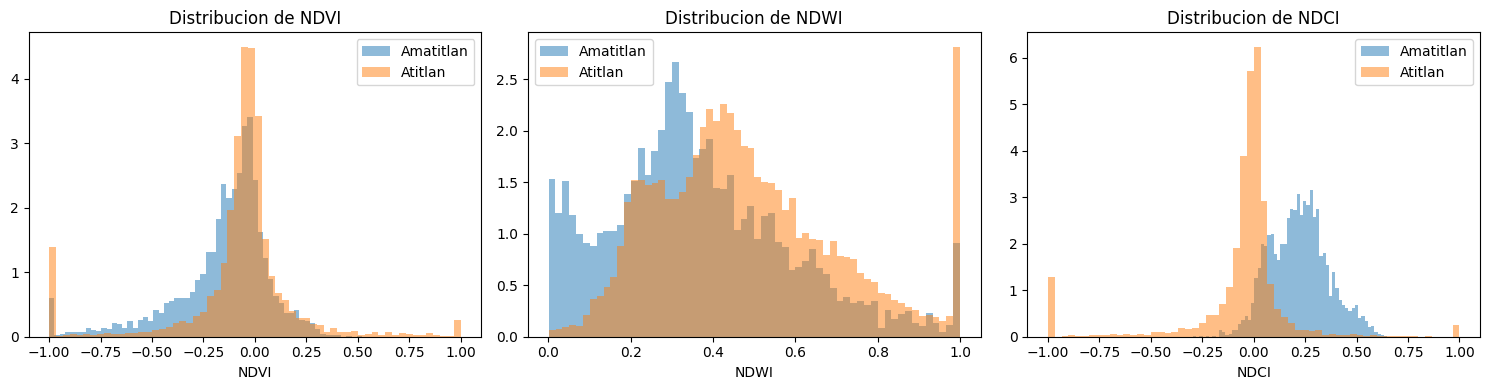

In [103]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["NDVI", "NDWI", "NDCI"]):
    for lake_name, group in ml_dataset.groupby("lake"):
        ax.hist(group[col], bins=60, alpha=0.5, label=lake_name, density=True)
    ax.set_title(f"Distribucion de {col}")
    ax.set_xlabel(col)
    ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "eda_histogramas_indices.png", dpi=150, bbox_inches="tight")
plt.show()

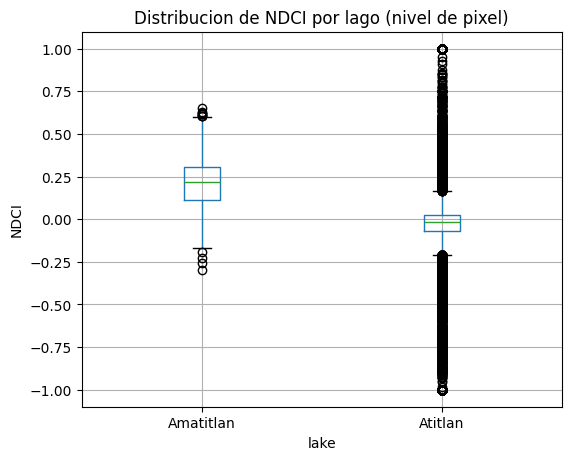

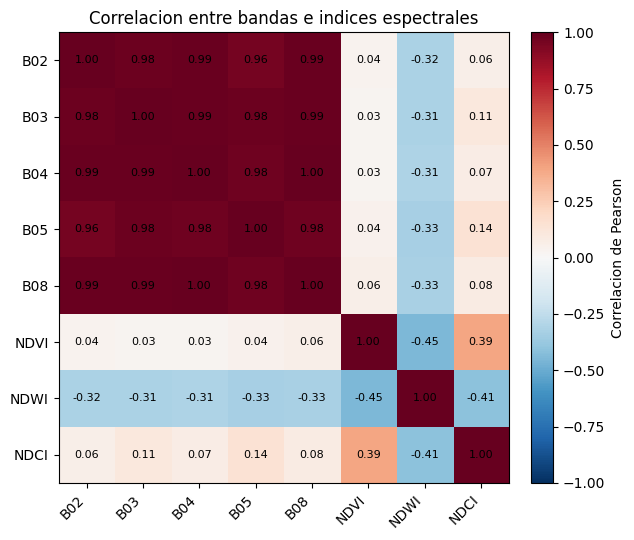

In [104]:
fig, ax = plt.subplots(figsize=(6, 5))
ml_dataset.boxplot(column="NDCI", by="lake", ax=ax)
ax.set_title("Distribucion de NDCI por lago (nivel de pixel)")
ax.set_ylabel("NDCI")
plt.suptitle("")
fig.savefig(OUT_DIR / "eda_boxplot_ndci_lago.png", dpi=150, bbox_inches="tight")
plt.show()

corr_cols = ["B02", "B03", "B04", "B05", "B08", "NDVI", "NDWI", "NDCI"]
corr = ml_dataset[corr_cols].corr()
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Correlacion de Pearson")
ax.set_title("Correlacion entre bandas e indices espectrales")
fig.tight_layout()
fig.savefig(OUT_DIR / "eda_correlacion_bandas.png", dpi=150, bbox_inches="tight")
plt.show()

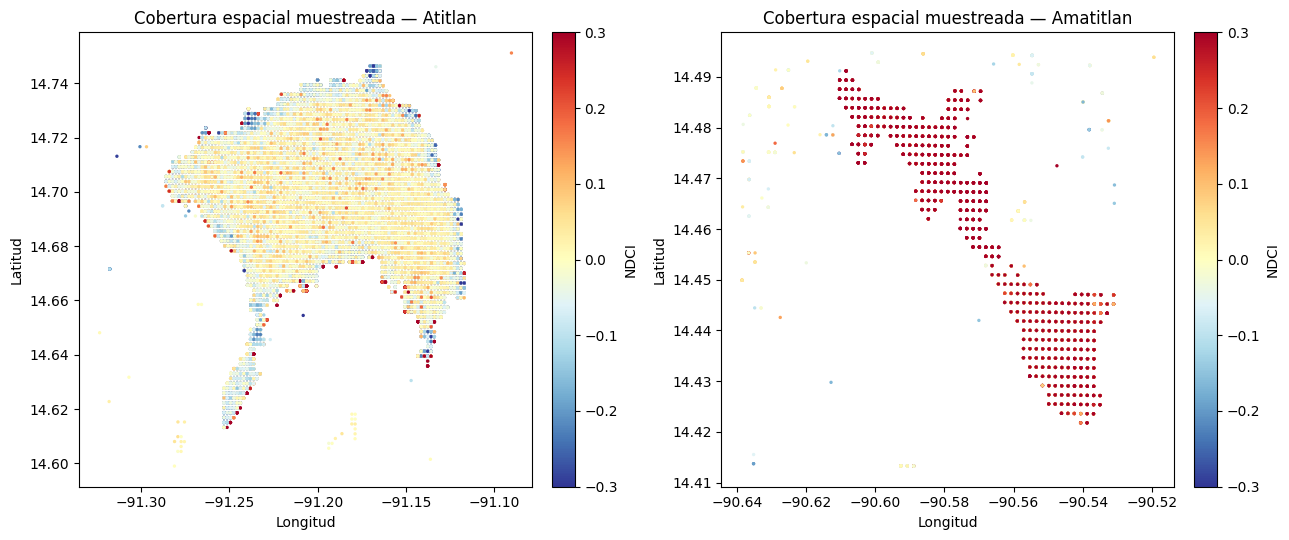

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, lake_name in zip(axes, LAKES):
    sub = ml_dataset[ml_dataset["lake"] == lake_name]
    sc = ax.scatter(sub["lon"], sub["lat"], c=sub["NDCI"], cmap="RdYlBu_r", s=2, vmin=-0.3, vmax=0.3)
    ax.set_title(f"Cobertura espacial muestreada — {lake_name}")
    ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
    fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, label="NDCI")
fig.tight_layout()
fig.savefig(OUT_DIR / "eda_cobertura_espacial.png", dpi=150, bbox_inches="tight")
plt.show()

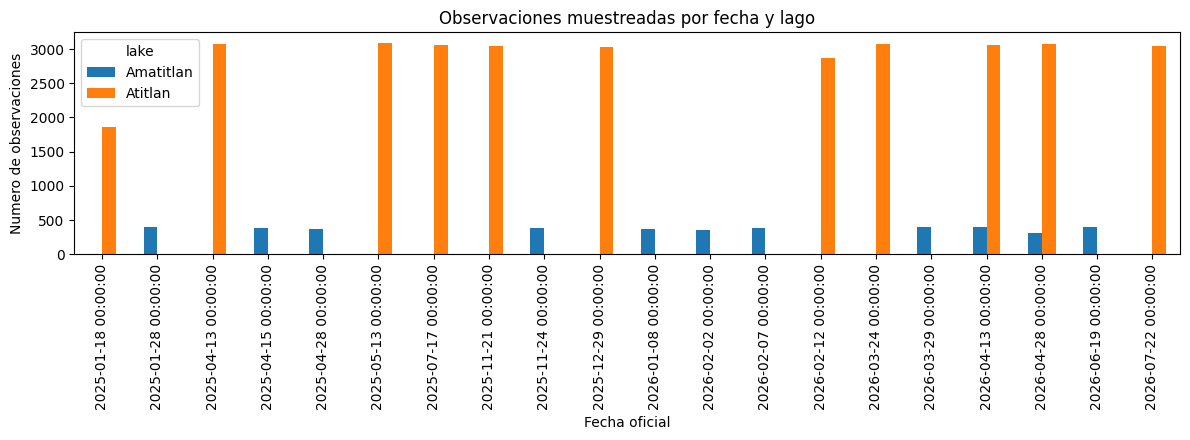

In [106]:
fig, ax = plt.subplots(figsize=(12, 4.5))
counts = ml_dataset.groupby(["date", "lake"]).size().unstack("lake")
counts.plot(kind="bar", ax=ax)
ax.set_ylabel("Numero de observaciones")
ax.set_xlabel("Fecha oficial")
ax.set_title("Observaciones muestreadas por fecha y lago")
fig.tight_layout()
fig.savefig(OUT_DIR / "eda_observaciones_por_fecha.png", dpi=150, bbox_inches="tight")
plt.show()

### 1.6 Decisiones tomadas durante la preparación y limpieza de los datos

- **Reutilización del caché de la Parte I:** las escenas Sentinel-2 (GeoTIFF) descargadas para `Lab4.ipynb` se reutilizan directamente (`download_scene` solo descarga si el archivo no existe), evitando volver a consultar la API y garantizando exactamente las mismas 22 escenas (2 lagos × 11 fechas oficiales).

- **Máscara de nubes (SCL):** se excluyen píxeles nodata, saturados, con sombra de nube, nube (media/alta probabilidad, cirros) y nieve/hielo, replicando el criterio de la Parte I.

- **Máscara de agua (NDWI > 0) en lugar del bounding box:** como no existe un GeoJSON oficial de los lagos en el repositorio, la Parte I usó el bounding box como respaldo, el cual incluye tierra alrededor del lago. Para esta Parte II, donde cada fila debe ser una "observación geográfica válida dentro de alguno de los lagos" (Ejercicio 1.1), esto es insuficiente. Se añade un filtro `NDWI > 0` (umbral estándar de McFeeters, 1996, para distinguir agua de superficies no acuáticas) que excluye la mayoría de píxeles de tierra dentro del bounding box. **Limitación conocida:** este es un proxy, no un polígono batimétrico real; en la orilla puede haber algo de error de inclusión/exclusión. Si en el futuro se consigue el GeoJSON oficial de los lagos, debería preferirse sobre este proxy.

- **Escalamiento de reflectancia:** las bandas Sentinel-2 L2A se dividen entre 10000 para obtener reflectancia de superficie en el rango [0, 1], igual que en la Parte I.

- **Sistema de coordenadas:** cada escena se descarga en su CRS proyectado nativo (UTM de la zona correspondiente); las coordenadas de cada observación se reproyectan a `EPSG:4326` (longitud/latitud) para tener un sistema común e interpretable entre fechas y lagos. Para el Ejercicio 6 (validación espacial) se reproyectará a `EPSG:32615` según lo exige la guía.

- **Muestreo sistemático espacial (`SAMPLE_STRIDE_PX = 20`, ~200 m de espaciamiento):** usar cada píxel válido a 10 m de resolución nativa generaría decenas de millones de observaciones (aprox. 49.6 M para Atitlán y 13.3 M para Amatitlán solo considerando píxeles válidos, sin contar el filtro de agua adicional), lo cual es computacionalmente inviable para entrenar e interpretar modelos (incluido SHAP en el Ejercicio 8) y, más importante, **viola el supuesto de observaciones independientes**: píxeles vecinos a 10 m están masivamente autocorrelacionados espacialmente (el mismo parche de agua), por lo que tratarlos como observaciones i.i.d. infla artificialmente el desempeño de una partición aleatoria. Se aplica un muestreo sistemático (cuadrícula regular) con el mismo paso físico para ambos lagos, de modo que la densidad de observaciones por km² sea comparable entre lagos y el número total de filas por lago refleje su tamaño real. Este espaciamiento (~200 m) también deja múltiples observaciones dentro de cada bloque espacial de ~1 km × 1 km que se usará en el Ejercicio 6, lo cual es necesario para que esa validación espacial tenga sentido. El valor de `SAMPLE_STRIDE_PX` queda como parámetro ajustable si se requiere un dataset más grande o más pequeño.

## Ejercicio 2. Construcción de la variable respuesta

### 2.1–2.2 Variable binaria y justificación del punto de corte

La variable respuesta se basa en el **NDCI** (`(B05-B04)/(B05+B04)`), el índice espectral de clorofila-a/cianobacteria calculado en la Parte I. Para justificar el punto de corte se combinan tres fuentes:

1. **Mishra, S., & Mishra, D. R. (2012).** *Normalized Difference Chlorophyll Index: A novel model for remote estimation of chlorophyll-a concentration in turbid productive waters.* Remote Sensing of Environment, 117, 394–406. Este trabajo introdujo el NDCI usando reflectancias en ~665 nm y ~705 nm (equivalentes a las bandas Sentinel-2 B04 y B05 usadas aquí) y demostró una relación cuadrática/cúbica robusta (R² ≈ 0.9–0.95) entre NDCI y la concentración real de clorofila-a medida en campo, en un rango de 1 a 60 mg/m³.

2. **Sentinel Hub — Custom script "Cyanobacteria / Chlorophyll-a (NDCI, L1C)"** (https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/cyanobacteria_chla_ndci_l1c/), la misma fuente que originó el umbral exploratorio de 0.20 usado en la Parte I. Este script opera con la misma fórmula de NDCI y la convierte a clorofila-a (µg/L) mediante el modelo cúbico calibrado:

   `chl_a = 826.57·NDCI³ − 176.43·NDCI² + 19·NDCI + 4.071`

3. **Chorus, I., & Bartram, J. (Eds.). (1999).** *Toxic Cyanobacteria in Water: A guide to their public health consequences, monitoring and management.* World Health Organization. Y su actualización más reciente sobre ambientes recreativos (OMS, guías de "niveles de alerta"), que definen umbrales operativos de riesgo por floración de cianobacterias en términos de clorofila-a: el **Nivel de Alerta 1** (probabilidad de efectos adversos "baja a moderada", inicio de vigilancia) corresponde aproximadamente a **10–12 µg/L de clorofila-a** con dominancia de cianobacterias (valor de 12 µg/L / 3 mm³/L de biovolumen usado en el marco de niveles por tramos más reciente de la OMS para aguas recreativas); el **Nivel de Alerta 2** (riesgo moderado a alto, posible formación de espuma tóxica) corresponde a ~50 µg/L.

Usando la fórmula cúbica del script de Sentinel Hub, se resuelve numéricamente qué valor de NDCI produce una clorofila-a equivalente de 12 µg/L (Nivel de Alerta 1 de la OMS), y se compara contra el umbral exploratorio de 0.20 ya usado en la Parte I.

In [107]:
def ndci_to_chla(ndci):
    """Modelo cubico NDCI -> clorofila-a (ug/L), calibrado por el script de cianobacteria de Sentinel Hub,
    basado en Mishra & Mishra (2012)."""
    return 826.57 * ndci**3 - 176.43 * ndci**2 + 19 * ndci + 4.071

# NDCI equivalente al Nivel de Alerta 1 de la OMS (~12 ug/L de clorofila-a).
poly_coeffs = [826.57, -176.43, 19, 4.071 - 12.0]
roots = np.roots(poly_coeffs)
real_roots = roots[np.isreal(roots)].real
ndci_who_alert1 = float(real_roots[(real_roots > 0) & (real_roots < 1)][0])
print(f"NDCI equivalente a 12 ug/L de clorofila-a (Nivel de Alerta 1, OMS): {ndci_who_alert1:.3f}")

NDCI_HIGH_THRESHOLD = 0.20
chla_en_umbral = ndci_to_chla(NDCI_HIGH_THRESHOLD)
print(f"Umbral exploratorio usado (Parte I y este avance): NDCI >= {NDCI_HIGH_THRESHOLD}")
print(f"Clorofila-a equivalente en ese umbral (modelo cubico): {chla_en_umbral:.2f} ug/L")
print(
    "Interpretacion: el umbral NDCI=0.20 es MAS CONSERVADOR (precautorio) que el Nivel de Alerta 1 de la OMS "
    f"(equivalente a NDCI~{ndci_who_alert1:.2f}); detecta floraciones antes de alcanzar el nivel de alerta formal, "
    "lo cual es apropiado para un sistema de monitoreo temprano orientado a ambientalistas."
)

ml_dataset["chla_eq_ugL"] = ndci_to_chla(ml_dataset["NDCI"])
ml_dataset["alta_cianobacteria"] = (ml_dataset["NDCI"] >= NDCI_HIGH_THRESHOLD).astype(int)
ml_dataset[["NDCI", "chla_eq_ugL", "alta_cianobacteria"]].describe()

NDCI equivalente a 12 ug/L de clorofila-a (Nivel de Alerta 1, OMS): 0.264
Umbral exploratorio usado (Parte I y este avance): NDCI >= 0.2
Clorofila-a equivalente en ese umbral (modelo cubico): 7.43 ug/L
Interpretacion: el umbral NDCI=0.20 es MAS CONSERVADOR (precautorio) que el Nivel de Alerta 1 de la OMS (equivalente a NDCI~0.26); detecta floraciones antes de alcanzar el nivel de alerta formal, lo cual es apropiado para un sistema de monitoreo temprano orientado a ambientalistas.


,NDCI,chla_eq_ugL,alta_cianobacteria
count,36442.000000,36442.000000,36442.000000
mean,-0.027305,-36.203682,0.100681
std,0.268434,211.207352,0.300909
min,-1.000000,-1017.929016,0.000000
25%,-0.056604,2.280344,0.000000
50%,-0.004695,3.977823,0.000000
75%,0.047619,4.664947,0.000000
max,1.000000,673.210999,1.000000


### 2.3 Distribución de la variable respuesta

Distribucion global:


,proporcion
alta_cianobacteria,
baja/ausente (0),0.899319
alta (1),0.100681



Proporcion de 'alta_cianobacteria' por lago:


,proporcion_alta
lake,
Amatitlan,0.563146
Atitlan,0.041134



Proporcion de 'alta_cianobacteria' por lago y fecha:


proporcion_alta
lake      date                       
Amatitlan 2025-01-28         0.796438
          2025-04-15         0.287958
          2025-04-28         0.427807
          2025-11-24         0.358247
          2026-01-08         0.800000
          2026-02-02         0.156695
          2026-02-07         0.387179
          2026-03-29         0.673418
          2026-04-13         0.896203
          2026-04-28         0.457680
          2026-06-19         0.876543
Atitlan   2025-01-18         0.223712
          2025-04-13         0.009103
          2025-05-13         0.007767
          2025-07-17         0.014691
          2025-11-21         0.128863
          2025-12-29         0.054713
          2026-02-12         0.052374
          2026-03-24         0.008143
          2026-04-13         0.008162
          2026-04-28         0.007825
          2026-07-22         0.010485

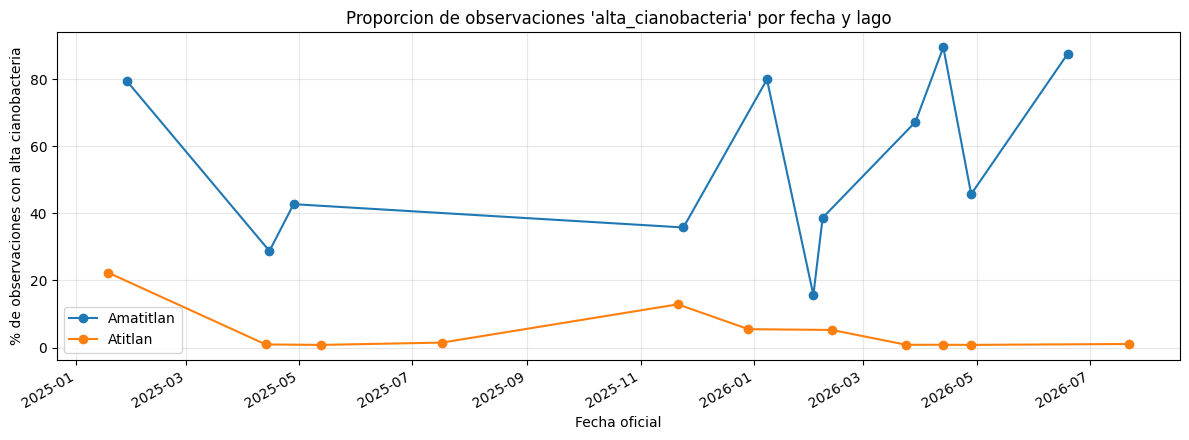

In [108]:
overall = ml_dataset["alta_cianobacteria"].value_counts(normalize=True).rename("proporcion").to_frame()
overall.index = overall.index.map({0: "baja/ausente (0)", 1: "alta (1)"})
print("Distribucion global:")
display(overall)

por_lago = ml_dataset.groupby("lake")["alta_cianobacteria"].mean().to_frame("proporcion_alta")
print("\nProporcion de 'alta_cianobacteria' por lago:")
display(por_lago)

por_fecha = ml_dataset.groupby(["lake", "date"])["alta_cianobacteria"].mean().to_frame("proporcion_alta")
print("\nProporcion de 'alta_cianobacteria' por lago y fecha:")
display(por_fecha)

fig, ax = plt.subplots(figsize=(12, 4.5))
for lake_name, group in ml_dataset.groupby("lake"):
    serie = group.groupby("date")["alta_cianobacteria"].mean().sort_index()
    ax.plot(serie.index, 100 * serie.values, marker="o", label=lake_name)
ax.set_ylabel("% de observaciones con alta cianobacteria")
ax.set_xlabel("Fecha oficial")
ax.set_title("Proporcion de observaciones 'alta_cianobacteria' por fecha y lago")
ax.legend(); ax.grid(alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUT_DIR / "distribucion_variable_respuesta.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.4 Desbalance de clases

Se cuantifica la razón entre clases y se discuten las consecuencias para el entrenamiento/evaluación de los modelos.

In [109]:
class_counts = ml_dataset["alta_cianobacteria"].value_counts().sort_index()
ratio = class_counts[1] / class_counts[0] if 0 in class_counts.index and class_counts[0] > 0 else float("nan")
print(f"Clase 0 (baja/ausente): {class_counts.get(0, 0):,} observaciones")
print(f"Clase 1 (alta): {class_counts.get(1, 0):,} observaciones")
print(f"Razon clase1:clase0 = {ratio:.2f} : 1")
print(f"Proporcion de la clase minoritaria: {100 * min(class_counts) / class_counts.sum():.1f}%")

Clase 0 (baja/ausente): 32,773 observaciones
Clase 1 (alta): 3,669 observaciones
Razon clase1:clase0 = 0.11 : 1
Proporcion de la clase minoritaria: 10.1%


**Consecuencias del desbalance (a evaluar formalmente con la proporción obtenida arriba):**

- Si una clase domina claramente, un modelo trivial que siempre prediga la clase mayoritaria puede alcanzar un **Accuracy** engañosamente alto sin tener ninguna capacidad real de detectar floraciones — por eso el Ejercicio 5 exige reportar también Precision, Recall, F1 y ROC-AUC, no solo Accuracy.
- El **Recall de la clase "alta cianobacteria"** es la métrica más sensible al desbalance: con pocas observaciones positivas, el modelo tiende a "aprender" a favorecer la clase mayoritaria y a subestimar la minoritaria (más falsos negativos), que es justamente el error más costoso desde el punto de vista ambiental (no detectar una floración real).
- Implicaciones para el entrenamiento (a aplicar en el Ejercicio 4): usar `class_weight="balanced"` (Regresión Logística, Random Forest) o `scale_pos_weight` (XGBoost/Gradient Boosting), y validar con **partición estratificada** para que el conjunto de prueba conserve la misma proporción de clases que el conjunto completo.
- Implicaciones para la validación espacial (Ejercicio 6) y entre lagos (Ejercicio 7): si el desbalance difiere entre lagos o zonas espaciales, la comparación de métricas entre esos subconjuntos debe hacerse con cuidado (una métrica sensible al desbalance, como Accuracy, puede variar solo porque cambió la proporción de clases, no porque el modelo generalice peor).

### 2.5 Variables que no pueden usarse como predictoras (fuga de información)

La variable respuesta `alta_cianobacteria` se construye directamente a partir de `NDCI`, y `NDCI = (B05 − B04) / (B05 + B04)`. Siguiendo la instrucción de la guía ("una variable utilizada directa o indirectamente para construir la variable respuesta no deberá incluirse como predictora"):

| Variable | Motivo de exclusión |
|---|---|
| `NDCI` | Fuga **directa**: es exactamente la variable con la que se definió el umbral y la clase. |
| `chla_eq_ugL` | Fuga **directa**: es una transformación determinista 1-a-1 de `NDCI` (permitiría reconstruir `NDCI` y, con ello, la etiqueta, de forma casi perfecta). |
| `B05` | Fuga **indirecta**: junto con `B04`, determina algebraicamente el valor exacto de `NDCI`. Dejarla como predictora permitiría a un modelo reconstruir `NDCI` (y la etiqueta) casi exactamente, sin aprender ninguna relación ambiental real. |
| `B04` | Misma razón que `B05`: interviene directamente en la fórmula de `NDCI`. |

**Nota sobre NDVI:** `NDVI = (B08 − B04) / (B08 + B04)` también usa `B04`, la misma banda que interviene en `NDCI`. Estrictamente, esto introduce una fuga *parcial* (no una reconstrucción exacta de `NDCI`, porque `NDVI` no contiene información equivalente a `B05`). Se decide **conservar `NDVI` como predictora** porque (a) la guía la exige explícitamente como variable mínima del conjunto de datos, y (b) a diferencia de `B04`/`B05`, no permite recuperar el valor exacto de `NDCI` ni de la etiqueta — el riesgo de fuga "trivial" (reconstrucción exacta) queda eliminado al excluir `B04` y `B05`, que es el riesgo real que la instrucción busca evitar.

**Conjunto final excluido como predictor por fuga de información:** `NDCI`, `chla_eq_ugL`, `B04`, `B05`.

## Ejercicio 3. Selección y construcción de variables predictoras

### 3.1–3.2 Conjunto de variables predictoras y justificación

| Variable | Tipo | Qué representa | Por qué podría contribuir |
|---|---|---|---|
| `B02` (azul) | Banda espectral | Reflectancia de superficie en azul (~490 nm) | Sensible a turbidez y dispersión por partículas en suspensión; ayuda a distinguir agua clara de agua con carga de sedimento/algas. |
| `B03` (verde) | Banda espectral | Reflectancia en verde (~560 nm) | El pico de reflectancia de la clorofila-a está cerca del verde; interviene también en `NDWI`. |
| `B08` (NIR) | Banda espectral | Reflectancia en infrarrojo cercano (~842 nm) | El agua absorbe fuertemente el NIR; concentraciones altas de biomasa algal en superficie elevan la reflectancia NIR de forma medible (scattering celular), a diferencia del agua limpia. |
| `NDVI` | Índice espectral | `(B08−B04)/(B08+B04)` | Aunque es un índice de vegetación terrestre, valores positivos anómalos sobre una superficie de agua suelen asociarse a biomasa fotosintética en superficie (posible proxy de biomasa algal/vegetación acuática flotante). Exigido explícitamente por la guía. |
| `NDWI` | Índice espectral | `(B03−B08)/(B03+B08)` | Confirma que la observación corresponde a agua (ya usado como filtro en el Ejercicio 1) y su magnitud varía con turbidez/profundidad óptica, lo que puede modular la señal de cianobacteria. Exigido explícitamente por la guía. |
| `lon`, `lat` | Característica espacial | Coordenadas geográficas (EPSG:4326) del píxel | Capturan gradientes espaciales persistentes (p. ej. cercanía a afluentes o zonas de descarga) — ver Ejercicio 5.3 de la Parte I, donde ciertos cuadrantes concentran más NDCI de forma sistemática. **Nota metodológica:** se incluyen deliberadamente para poder mostrar en el Ejercicio 6 cuánto infla el desempeño una partición aleatoria frente a una partición espacial, dado que la ubicación está fuertemente autocorrelacionada con la variable respuesta. |
| `month` / `doy_sin`, `doy_cos` | Característica temporal | Mes y codificación cíclica del día del año | Captura estacionalidad (ver hallazgo de la Parte I, sección 8.4: NDCI algo mayor en temporada lluviosa, más marcado en Amatitlán). La codificación seno/coseno evita la discontinuidad artificial de diciembre→enero. |

**Variable deliberadamente excluida como predictora: `lake`.** Aunque no interviene en la construcción de la variable respuesta (no hay fuga de información en sentido estricto), se excluye del conjunto de predictores porque el Ejercicio 7 evalúa explícitamente la **generalización entre lagos** (entrenar en uno, evaluar en el otro). Si `lake` se codificara como variable categórica, el modelo podría aprender un efecto fijo específico de cada lago; al evaluar sobre el lago no visto, esa categoría estaría ausente en entrenamiento, lo que rompe la comparación y no mide generalización real basada en las características espectrales/espaciales. `lake` se conserva como columna de metadato para agrupar, dividir y reportar resultados, pero no entra al vector de predictores del modelo.

### 3.3 Ingeniería de características

Se agregan dos tipos de variables derivadas:

1. **Estacionalidad continua (`doy_sin`, `doy_cos`):** codificación cíclica del día del año, preferible a usar el mes o el día del año como número entero porque evita que el modelo interprete diciembre (día 365) y enero (día 1) como extremos opuestos.
2. **Razón verde/rojo (`green_red_ratio = B03/B04`):** un proxy espectral simple de pigmentación relacionado con clorofila y turbidez, complementario a `NDVI`/`NDWI`, sin depender de `B05` (evita reintroducir fuga de información).

In [110]:
def season_of(month):
    return "seca (nov-abr)" if month in (11, 12, 1, 2, 3, 4) else "lluviosa (may-oct)"

ml_dataset["month"] = ml_dataset["date"].dt.month
ml_dataset["day_of_year"] = ml_dataset["date"].dt.dayofyear
ml_dataset["season"] = ml_dataset["month"].apply(season_of)
ml_dataset["doy_sin"] = np.sin(2 * np.pi * ml_dataset["day_of_year"] / 365.25)
ml_dataset["doy_cos"] = np.cos(2 * np.pi * ml_dataset["day_of_year"] / 365.25)
raw_ratio = ml_dataset["B03"] / ml_dataset["B04"].replace(0, np.nan)
# Winsorizacion (percentiles 1-99): B04 cercano a 0 (agua muy oscura, comun en Atitlan) dispara
# el cociente a valores extremos que desestabilizan numericamente la Regresion Logistica
# (RuntimeWarning: overflow/divide by zero en el optimizador), incluso tras estandarizar.
ratio_low, ratio_high = raw_ratio.quantile([0.01, 0.99])
ml_dataset["green_red_ratio"] = raw_ratio.clip(ratio_low, ratio_high).fillna(raw_ratio.median())

LEAKAGE_EXCLUDED = ["NDCI", "chla_eq_ugL", "B04", "B05"]
PREDICTOR_COLUMNS = ["B02", "B03", "B08", "NDVI", "NDWI", "lon", "lat", "doy_sin", "doy_cos", "green_red_ratio"]
METADATA_COLUMNS = ["lake", "date", "row", "col", "season", "month"]
TARGET_COLUMN = "alta_cianobacteria"

print("Predictoras:", PREDICTOR_COLUMNS)
print("Excluidas por fuga de informacion:", LEAKAGE_EXCLUDED)
print("Metadato (no predictoras):", METADATA_COLUMNS)

ml_dataset.to_csv(OUT_DIR / "ml_dataset_features.csv", index=False)
print(f"\nDataset final guardado en: {(OUT_DIR / 'ml_dataset_features.csv').resolve()}")
print(f"Filas: {len(ml_dataset):,} | Columnas: {ml_dataset.shape[1]}")
ml_dataset[METADATA_COLUMNS + PREDICTOR_COLUMNS + [TARGET_COLUMN]].head()

Predictoras: ['B02', 'B03', 'B08', 'NDVI', 'NDWI', 'lon', 'lat', 'doy_sin', 'doy_cos', 'green_red_ratio']
Excluidas por fuga de informacion: ['NDCI', 'chla_eq_ugL', 'B04', 'B05']
Metadato (no predictoras): ['lake', 'date', 'row', 'col', 'season', 'month']

Dataset final guardado en: /Users/dijan/Documents/U/Data Science/Lab4/data/GIS/lab4_parte2/ml_dataset_features.csv
Filas: 36,442 | Columnas: 22


,lake,date,row,col,season,month,B02,B03,B08,NDVI,NDWI,lon,lat,doy_sin,doy_cos,green_red_ratio,alta_cianobacteria
0,Atitlan,2025-01-18,60,1740,seca (nov-abr),1,0.0106,0.0096,0.0000,-1.000000,1.000000,-91.164735,14.746331,0.304719,0.952442,24.000002,0
1,Atitlan,2025-01-18,80,1660,seca (nov-abr),1,0.0124,0.0114,0.0026,0.209302,0.628571,-91.172179,14.744583,0.304719,0.952442,6.705883,0
2,Atitlan,2025-01-18,100,1640,seca (nov-abr),1,0.0119,0.0093,0.0000,-1.000000,1.000000,-91.174051,14.742790,0.304719,0.952442,15.499999,1
3,Atitlan,2025-01-18,120,1360,seca (nov-abr),1,0.0132,0.0102,0.0059,0.638889,0.267081,-91.200067,14.741186,0.304719,0.952442,7.846154,0
4,Atitlan,2025-01-18,120,1440,seca (nov-abr),1,0.0168,0.0131,0.0014,-0.222222,0.806897,-91.192638,14.741128,0.304719,0.952442,5.954545,0


## Ejercicio 4. Construcción de modelos de Machine Learning

Dependencias adicionales para los Ejercicios 4-9 (si falta alguna): `pip install scikit-learn shap xgboost`. `xgboost` es opcional: si no está instalado, el notebook usa automáticamente `GradientBoostingClassifier` de scikit-learn como respaldo.

### 4.1-4.2 Variables, partición 70/30

Se parte del dataset final del Ejercicio 3 (`ml_dataset_features.csv`), usando `PREDICTOR_COLUMNS` como predictoras y `TARGET_COLUMN` (`alta_cianobacteria`) como respuesta — excluyendo explícitamente las variables con fuga de información (`NDCI`, `chla_eq_ugL`, `B04`, `B05`) y `lake` (ver Ejercicios 2.5 y 3.2). La partición es **estratificada** para conservar la proporción de clases (Ejercicio 2.4) en entrenamiento y prueba.

In [111]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [112]:
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV, GroupKFold, StratifiedKFold, cross_val_score, train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False

RANDOM_STATE = 42
print("XGBoost disponible:", HAS_XGBOOST)

XGBoost disponible: False


In [113]:
ml_dataset = pd.read_csv(OUT_DIR / "ml_dataset_features.csv", parse_dates=["date"])

X = ml_dataset[PREDICTOR_COLUMNS].copy()
y = ml_dataset[TARGET_COLUMN].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE,
)
print(f"Entrenamiento: {len(X_train):,} obs | Prueba: {len(X_test):,} obs")
print(f"Proporcion clase 1 en entrenamiento: {y_train.mean():.3f} | en prueba: {y_test.mean():.3f}")

Entrenamiento: 25,509 obs | Prueba: 10,933 obs
Proporcion clase 1 en entrenamiento: 0.101 | en prueba: 0.101


### 4.3 Modelos y ajuste de hiperparámetros

Para cada modelo se usa `GridSearchCV` con validación cruzada estratificada de 5 folds sobre el conjunto de entrenamiento, optimizando **F1 de la clase positiva** (no Accuracy: ver justificación en el Ejercicio 2.4, el problema está desbalanceado ~13% clase positiva). Hiperparámetros explorados:

- **Regresión Logística:** `C` ∈ {0.01, 0.1, 1, 10}, con `class_weight="balanced"` fijo.
- **Random Forest:** `n_estimators` ∈ {200, 400}, `max_depth` ∈ {None, 10, 20}, con `class_weight="balanced"`.
- **Gradient Boosting / XGBoost:** `n_estimators` ∈ {200, 400}, `max_depth` ∈ {3, 5}, `learning_rate` ∈ {0.05, 0.1}. Para XGBoost, el desbalance se compensa con `scale_pos_weight`; para el respaldo de scikit-learn (sin soporte nativo de peso de clase), el desbalance se maneja en la etapa de evaluación priorizando Recall/F1 (Ejercicio 5.3) en vez de en el entrenamiento.

In [114]:
def build_models():
    models = {}
    models["Regresion Logistica"] = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)),
    ])
    models["Random Forest"] = RandomForestClassifier(
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1,
    )
    if HAS_XGBOOST:
        neg, pos = np.bincount(y_train)
        models["Gradient Boosting"] = XGBClassifier(
            random_state=RANDOM_STATE, eval_metric="logloss", scale_pos_weight=neg / pos,
        )
    else:
        models["Gradient Boosting"] = GradientBoostingClassifier(random_state=RANDOM_STATE)
    return models

PARAM_GRIDS = {
    "Regresion Logistica": {"clf__C": [0.01, 0.1, 1, 10]},
    "Random Forest": {"n_estimators": [200, 400], "max_depth": [None, 10, 20]},
    "Gradient Boosting": {"n_estimators": [200, 400], "max_depth": [3, 5], "learning_rate": [0.05, 0.1]},
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

best_models = {}
tuning_summary = []
for name, base_model in build_models().items():
    grid = GridSearchCV(base_model, PARAM_GRIDS[name], scoring="f1", cv=cv_strategy, n_jobs=-1)
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_
    tuning_summary.append({"modelo": name, "mejores_hiperparametros": str(grid.best_params_), "f1_cv": grid.best_score_})
    print(f"{name}: mejores hiperparametros = {grid.best_params_} (F1 CV = {grid.best_score_:.3f})")

tuning_df = pd.DataFrame(tuning_summary)
tuning_df.to_csv(OUT_DIR / "ajuste_hiperparametros.csv", index=False)
display(tuning_df)

/Users/dijan/Documents/U/Data Science/Lab4/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dijan/Documents/U/Data Science/Lab4/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dijan/Documents/U/Data Science/Lab4/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dijan/Documents/U/Data Science/Lab4/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dijan/Documents/U/Data Science/Lab4/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow enc

Regresion Logistica: mejores hiperparametros = {'clf__C': 0.1} (F1 CV = 0.642)
Random Forest: mejores hiperparametros = {'max_depth': 20, 'n_estimators': 400} (F1 CV = 0.807)
Gradient Boosting: mejores hiperparametros = {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 400} (F1 CV = 0.813)


,modelo,mejores_hiperparametros,f1_cv
0,Regresion Logistica,{'clf__C': 0.1},0.641511
1,Random Forest,"{'max_depth': 20, 'n_estimators': 400}",0.807435
2,Gradient Boosting,"{'learning_rate': 0.05, 'max_depth': 5, 'n_est...",0.812513


### 4.4 Conjunto de prueba común

El mismo `X_test`/`y_test` (30% reservado arriba) se usa para evaluar los tres modelos en el Ejercicio 5, garantizando una comparación justa.

## Ejercicio 5. Evaluación de los modelos

### 5.1 Métricas y matrices de confusión

In [115]:
def evaluate_model(name, model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]
    metrics = {
        "modelo": name,
        "accuracy": accuracy_score(y_eval, y_pred),
        "precision": precision_score(y_eval, y_pred, zero_division=0),
        "recall": recall_score(y_eval, y_pred, zero_division=0),
        "f1": f1_score(y_eval, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_eval, y_proba),
    }
    return metrics, y_pred, y_proba

eval_records = []
predictions = {}
for name, model in best_models.items():
    metrics, y_pred, y_proba = evaluate_model(name, model, X_test, y_test)
    eval_records.append(metrics)
    predictions[name] = {"y_pred": y_pred, "y_proba": y_proba}

eval_df = pd.DataFrame(eval_records).set_index("modelo")
eval_df.to_csv(OUT_DIR / "evaluacion_modelos.csv")
display(eval_df.round(3))

,accuracy,precision,recall,f1,roc_auc
modelo,,,,,
Regresion Logistica,0.897,0.492,0.875,0.630,0.946
Random Forest,0.964,0.888,0.734,0.804,0.983
Gradient Boosting,0.962,0.866,0.742,0.799,0.983


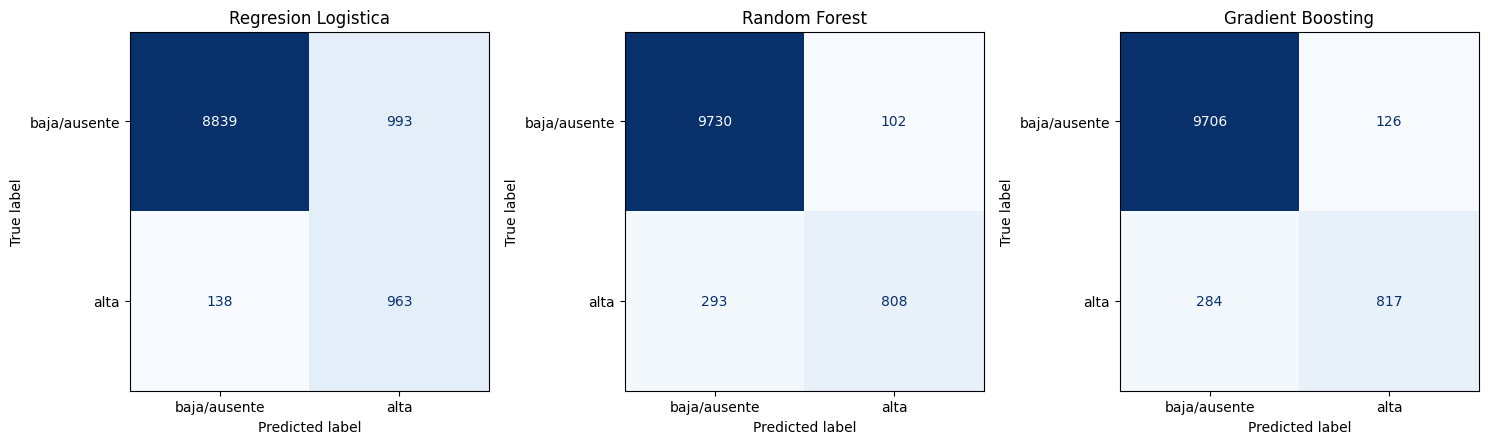

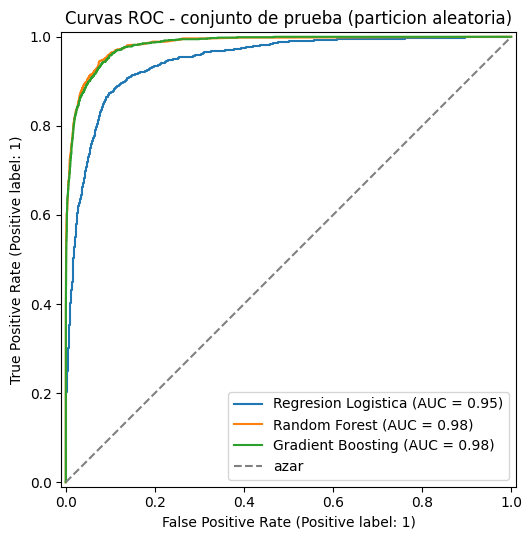

In [116]:
fig, axes = plt.subplots(1, len(best_models), figsize=(5 * len(best_models), 4.5))
for ax, (name, model) in zip(axes, best_models.items()):
    cm = confusion_matrix(y_test, predictions[name]["y_pred"])
    ConfusionMatrixDisplay(cm, display_labels=["baja/ausente", "alta"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
fig.tight_layout()
fig.savefig(OUT_DIR / "matrices_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
for name in best_models:
    RocCurveDisplay.from_predictions(y_test, predictions[name]["y_proba"], name=name, ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="azar")
ax.set_title("Curvas ROC - conjunto de prueba (particion aleatoria)")
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "curvas_roc.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.2 Comparación de modelos

In [117]:
best_by_f1 = eval_df["f1"].idxmax()
best_by_auc = eval_df["roc_auc"].idxmax()
print(f"Mejor modelo por F1: {best_by_f1} (F1={eval_df.loc[best_by_f1, 'f1']:.3f})")
print(f"Mejor modelo por ROC-AUC: {best_by_auc} (ROC-AUC={eval_df.loc[best_by_auc, 'roc_auc']:.3f})")

Mejor modelo por F1: Random Forest (F1=0.804)
Mejor modelo por ROC-AUC: Random Forest (ROC-AUC=0.983)


### 5.3 ¿Qué error ambiental es más costoso?

- **Falso negativo** (predecir "sin floración alta" cuando sí la hay): la zona queda sin monitoreo/alerta — riesgo directo para salud pública (exposición a toxinas), turismo y ecosistema. Es el error más grave y potencialmente irreversible.
- **Falso positivo** (predecir "floración alta" cuando no la hay): implica una verificación de campo innecesaria — costo operativo, pero reversible y menor.

Dado que el falso negativo es más costoso, la métrica de selección más adecuada es el **Recall de la clase "alta cianobacteria"** (complementado con ROC-AUC, que es independiente del umbral de decisión). Se elige el modelo con mayor Recall para los Ejercicios 8 y 9.

In [118]:
best_by_recall = eval_df["recall"].idxmax()
print(f"Mejor modelo segun el criterio ambientalmente mas relevante (Recall): {best_by_recall} "
      f"(Recall={eval_df.loc[best_by_recall, 'recall']:.3f})")

BEST_MODEL_NAME = best_by_recall
BEST_MODEL = best_models[BEST_MODEL_NAME]
print(f"\nModelo seleccionado para los Ejercicios 8 y 9: {BEST_MODEL_NAME}")

Mejor modelo segun el criterio ambientalmente mas relevante (Recall): Regresion Logistica (Recall=0.875)

Modelo seleccionado para los Ejercicios 8 y 9: Regresion Logistica


## Ejercicio 6. Validación espacial

### 6.1 Reproyección a EPSG:32615 y cuadrícula de ~1 km × 1 km

Se reproyectan las coordenadas de cada observación (`lon`/`lat`, EPSG:4326) a **WGS 84 / UTM zona 15N (EPSG:32615)**, en metros, tal como exige la guía. Antes de fijar el tamaño de bloque en 1 km, se calculan diagnósticos (número de bloques y observaciones por bloque, por lago); si 1 km no produce suficientes bloques con observaciones, se reduce automáticamente el tamaño y se justifica con los diagnósticos impresos.

In [119]:
import pyproj

def to_utm15n(lon, lat):
    transformer = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:32615", always_xy=True)
    x_arr, y_arr = transformer.transform(lon.values, lat.values)
    return x_arr, y_arr

ml_dataset["x_utm"], ml_dataset["y_utm"] = to_utm15n(ml_dataset["lon"], ml_dataset["lat"])
print("Coordenadas reproyectadas a EPSG:32615 (metros).")
ml_dataset[["lon", "lat", "x_utm", "y_utm"]].describe()

Coordenadas reproyectadas a EPSG:32615 (metros).


,lon,lat,x_utm,y_utm
count,36442.000000,36442.000000,36442.000000,3.644200e+04
mean,-91.123560,14.668934,702078.434224,1.622556e+06
std,0.203138,0.079562,21970.716995,8.614142e+03
min,-91.323363,14.413271,680565.000000,1.594795e+06
25%,-91.226316,14.672419,690965.000000,1.622875e+06
50%,-91.185628,14.693859,695365.000000,1.625275e+06
75%,-91.144871,14.712196,699765.000000,1.627275e+06
max,-90.519386,14.751151,767375.000000,1.631675e+06


In [120]:
def assign_blocks(df, block_size_m):
    blocks = df.copy()
    blocks["block_col"] = (blocks["x_utm"] // block_size_m).astype(int)
    blocks["block_row"] = (blocks["y_utm"] // block_size_m).astype(int)
    blocks["block_id"] = (
        blocks["lake"] + "_" + blocks["block_col"].astype(str) + "_" + blocks["block_row"].astype(str)
    )
    return blocks

def block_diagnostics(df, block_size_m, min_obs=5):
    blocks = assign_blocks(df, block_size_m)
    stats = []
    for lake_name, group in blocks.groupby("lake"):
        counts = group.groupby("block_id").size()
        stats.append({
            "lake": lake_name, "block_size_m": block_size_m, "n_blocks": len(counts),
            "n_blocks_validos": int((counts >= min_obs).sum()),
            "obs_por_bloque_mediana": counts.median(),
            "obs_por_bloque_min": int(counts.min()), "obs_por_bloque_max": int(counts.max()),
        })
    return blocks, pd.DataFrame(stats)

BLOCK_SIZE_M = 1000
blocks_df, block_stats = block_diagnostics(ml_dataset, BLOCK_SIZE_M)
print(f"Diagnostico con bloques de {BLOCK_SIZE_M} m:")
display(block_stats)

MIN_VALID_BLOCKS_PER_LAKE = 10
if (block_stats["n_blocks_validos"] < MIN_VALID_BLOCKS_PER_LAKE).any():
    print(
        f"\nAdvertencia: con bloques de {BLOCK_SIZE_M} m, al menos un lago tiene menos de "
        f"{MIN_VALID_BLOCKS_PER_LAKE} bloques con >=5 observaciones. Se reduce el tamano de bloque a 500 m "
        "para tener suficientes grupos para la validacion cruzada espacial (GroupKFold)."
    )
    BLOCK_SIZE_M = 500
    blocks_df, block_stats = block_diagnostics(ml_dataset, BLOCK_SIZE_M)
    print(f"Diagnostico con bloques de {BLOCK_SIZE_M} m:")
    display(block_stats)
else:
    print(f"\nBloques de {BLOCK_SIZE_M} m x {BLOCK_SIZE_M} m producen un numero suficiente de bloques validos por lago.")

ml_dataset = blocks_df
print(f"\nTamano de bloque final utilizado: {BLOCK_SIZE_M} m x {BLOCK_SIZE_M} m")

Diagnostico con bloques de 1000 m:


,lake,block_size_m,n_blocks,n_blocks_validos,obs_por_bloque_mediana,obs_por_bloque_min,obs_por_bloque_max
0,Amatitlan,1000,61,47,24.0,1,273
1,Atitlan,1000,181,163,256.0,1,275



Bloques de 1000 m x 1000 m producen un numero suficiente de bloques validos por lago.

Tamano de bloque final utilizado: 1000 m x 1000 m


### 6.2 Asignación y mapa de bloques

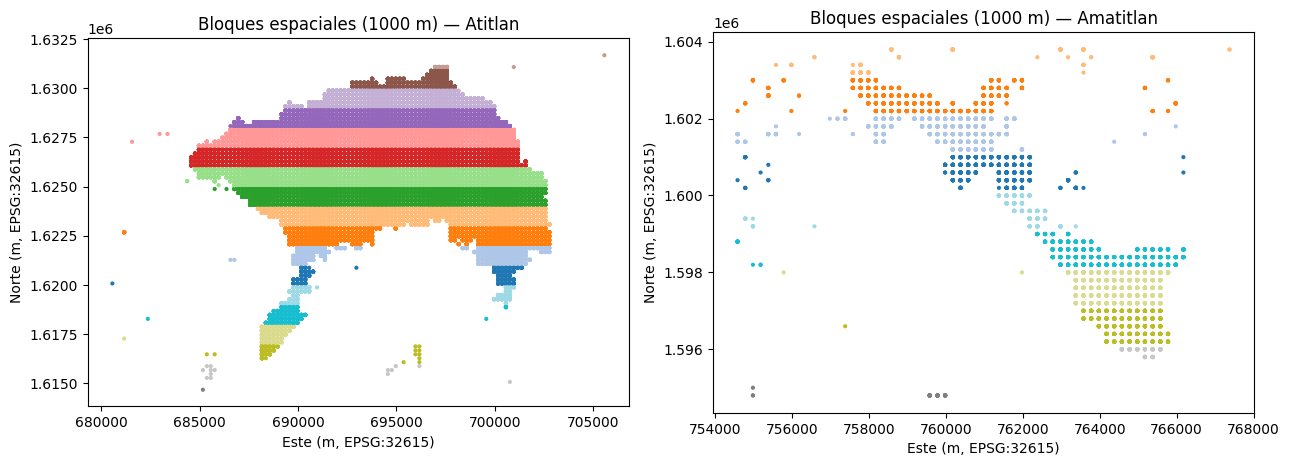

In [121]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, lake_name in zip(axes, LAKES):
    sub = ml_dataset[ml_dataset["lake"] == lake_name]
    block_code = sub["block_col"] * 10_000 + sub["block_row"]
    sc = ax.scatter(sub["x_utm"], sub["y_utm"], c=block_code % 20, cmap="tab20", s=4)
    ax.set_title(f"Bloques espaciales ({BLOCK_SIZE_M} m) — {lake_name}")
    ax.set_xlabel("Este (m, EPSG:32615)")
    ax.set_ylabel("Norte (m, EPSG:32615)")
    ax.set_aspect("equal")
fig.tight_layout()
fig.savefig(OUT_DIR / "bloques_espaciales.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.3-6.5 Validación aleatoria vs. espacial (GroupKFold)

Para una comparación justa, ambas estrategias se evalúan como validación cruzada de 5 folds sobre el conjunto de entrenamiento, usando los mismos hiperparámetros ya seleccionados en el Ejercicio 4 (`best_models`):

- **Aleatoria:** `StratifiedKFold` — ignora la ubicación; observaciones del mismo bloque pueden repartirse entre entrenamiento y validación.
- **Espacial:** `GroupKFold` usando `block_id` como grupo — todas las observaciones de un mismo bloque de ~1 km permanecen juntas en el mismo lado de cada partición.

In [122]:
block_train = ml_dataset.loc[X_train.index, "block_id"]

random_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
spatial_cv = GroupKFold(n_splits=5)

comparison_records = []
for name, model in best_models.items():
    random_scores = cross_val_score(model, X_train, y_train, cv=random_cv, scoring="f1", n_jobs=-1)
    spatial_scores = cross_val_score(
        model, X_train, y_train, cv=spatial_cv, groups=block_train, scoring="f1", n_jobs=-1,
    )
    comparison_records.append({
        "modelo": name,
        "f1_cv_aleatoria": random_scores.mean(),
        "f1_cv_espacial": spatial_scores.mean(),
        "diferencia (aleatoria - espacial)": random_scores.mean() - spatial_scores.mean(),
    })

comparison_df = pd.DataFrame(comparison_records).set_index("modelo")
display(comparison_df.round(3))

avg_diff = comparison_df["diferencia (aleatoria - espacial)"].mean()
print(f"\nDiferencia promedio (F1 aleatorio - F1 espacial) entre los 3 modelos: {avg_diff:+.3f}")

/Users/dijan/Documents/U/Data Science/Lab4/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dijan/Documents/U/Data Science/Lab4/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dijan/Documents/U/Data Science/Lab4/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dijan/Documents/U/Data Science/Lab4/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/dijan/Documents/U/Data Science/Lab4/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: 

,f1_cv_aleatoria,f1_cv_espacial,diferencia (aleatoria - espacial)
modelo,,,
Regresion Logistica,0.642,0.637,0.005
Random Forest,0.807,0.785,0.023
Gradient Boosting,0.813,0.790,0.022



Diferencia promedio (F1 aleatorio - F1 espacial) entre los 3 modelos: +0.017


### 6.6 Interpretación

Se espera que **F1 bajo validación aleatoria sea mayor que bajo validación espacial** (diferencia positiva arriba). La causa es la **autocorrelación espacial**: al muestrear la grilla cada ~200 m (Ejercicio 1.6), observaciones vecinas dentro de un mismo bloque de ~1 km comparten condiciones casi idénticas (misma zona del lago, reflectancias muy similares). Bajo partición aleatoria, el modelo suele ver en entrenamiento observaciones casi idénticas a las que luego evalúa en prueba, **inflando artificialmente el desempeño reportado**. `GroupKFold` por bloque elimina esa fuga implícita, forzando al modelo a predecir sobre zonas geográficas que nunca vio — una estimación **más realista** de la capacidad de generalizar a zonas nuevas del lago, que es el caso de uso real de un sistema de monitoreo. Por eso la validación espacial es la referencia más confiable para reportar el desempeño esperado en producción, aunque sus métricas sean más bajas.

### 6.7 Validación temporal (adicional, alineada con la rúbrica)

La guía numera explícitamente solo la validación espacial (6.1-6.6), pero la rúbrica de esta sección también pide una **estrategia de validación temporal**. Se implementa de forma análoga, agrupando por **fecha de adquisición** en vez de por bloque espacial (`GroupKFold` con `date` como grupo): todas las observaciones de una misma fecha quedan juntas en el mismo lado de cada partición, simulando predecir sobre una fecha futura no vista durante el entrenamiento.

In [123]:
date_train = ml_dataset.loc[X_train.index, "date"].astype(str)
temporal_cv = GroupKFold(n_splits=5)

temporal_records = []
for name, model in best_models.items():
    temporal_scores = cross_val_score(
        model, X_train, y_train, cv=temporal_cv, groups=date_train, scoring="f1", n_jobs=-1,
    )
    temporal_records.append({"modelo": name, "f1_cv_temporal": temporal_scores.mean()})

temporal_df = pd.DataFrame(temporal_records).set_index("modelo")
comparison_full_df = comparison_df.join(temporal_df)
comparison_full_df.to_csv(OUT_DIR / "comparacion_validacion_completa.csv")
display(comparison_full_df.round(3))

print(
    "\nAl igual que con la validacion espacial, se espera que F1 temporal sea menor o igual que F1 aleatorio: "
    "impide que el modelo 'memorice' condiciones especificas de una fecha vistas parcialmente en entrenamiento."
)

/Users/dijan/Documents/U/Data Science/Lab4/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dijan/Documents/U/Data Science/Lab4/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dijan/Documents/U/Data Science/Lab4/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dijan/Documents/U/Data Science/Lab4/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dijan/Documents/U/Data Science/Lab4/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow enc

,f1_cv_aleatoria,f1_cv_espacial,diferencia (aleatoria - espacial),f1_cv_temporal
modelo,,,,
Regresion Logistica,0.642,0.637,0.005,0.609
Random Forest,0.807,0.785,0.023,0.637
Gradient Boosting,0.813,0.790,0.022,0.670



Al igual que con la validacion espacial, se espera que F1 temporal sea menor o igual que F1 aleatorio: impide que el modelo 'memorice' condiciones especificas de una fecha vistas parcialmente en entrenamiento.


## Ejercicio 7. Generalización entre lagos

### 7.1-7.3 Experimentos A y B

In [124]:
def train_eval_cross_lake(train_lake, test_lake):
    train_mask = ml_dataset["lake"] == train_lake
    test_mask = ml_dataset["lake"] == test_lake
    X_tr = ml_dataset.loc[train_mask, PREDICTOR_COLUMNS]
    y_tr = ml_dataset.loc[train_mask, TARGET_COLUMN]
    X_te = ml_dataset.loc[test_mask, PREDICTOR_COLUMNS]
    y_te = ml_dataset.loc[test_mask, TARGET_COLUMN]

    records = []
    for name, fitted_model in best_models.items():
        model = clone(fitted_model)
        model.fit(X_tr, y_tr)
        metrics, _, _ = evaluate_model(name, model, X_te, y_te)
        records.append(metrics)
    return pd.DataFrame(records).set_index("modelo")

exp_a = train_eval_cross_lake("Atitlan", "Amatitlan")   # 7.1
exp_b = train_eval_cross_lake("Amatitlan", "Atitlan")    # 7.2

print("Experimento A: entrenado en Atitlan, evaluado en Amatitlan")
display(exp_a.round(3))
print("\nExperimento B: entrenado en Amatitlan, evaluado en Atitlan")
display(exp_b.round(3))

Experimento A: entrenado en Atitlan, evaluado en Amatitlan


,accuracy,precision,recall,f1,roc_auc
modelo,,,,,
Regresion Logistica,0.573,0.568,1.000,0.725,0.726
Random Forest,0.452,0.719,0.043,0.081,0.693
Gradient Boosting,0.593,0.581,0.997,0.734,0.726



Experimento B: entrenado en Amatitlan, evaluado en Atitlan


,accuracy,precision,recall,f1,roc_auc
modelo,,,,,
Regresion Logistica,0.042,0.041,1.000,0.079,0.775
Random Forest,0.081,0.042,0.986,0.081,0.350
Gradient Boosting,0.084,0.042,0.984,0.081,0.672


### 7.4 Comparación con entrenamiento/prueba del mismo conjunto (Ejercicio 5)

In [125]:
comparacion_generalizacion = pd.DataFrame({
    "mezcla_aleatoria_ambos_lagos (Ej.5)": eval_df["f1"],
    "entre_lagos A (Atitlan->Amatitlan)": exp_a["f1"],
    "entre_lagos B (Amatitlan->Atitlan)": exp_b["f1"],
})
comparacion_generalizacion.to_csv(OUT_DIR / "comparacion_generalizacion_lagos.csv")
display(comparacion_generalizacion.round(3))

,mezcla_aleatoria_ambos_lagos (Ej.5),entre_lagos A (Atitlan->Amatitlan),entre_lagos B (Amatitlan->Atitlan)
modelo,,,
Regresion Logistica,0.630,0.725,0.079
Random Forest,0.804,0.081,0.081
Gradient Boosting,0.799,0.734,0.081


### 7.5-7.6 ¿Generaliza un modelo entrenado en un lago al otro?

La tabla anterior responde empíricamente: si el F1 de los experimentos entre lagos es sustancialmente menor que el F1 con mezcla aleatoria de ambos lagos, la generalización es limitada. Hay razones ambientales concretas (ver Parte I) para esperar justo eso:

- **Profundidad y régimen óptico:** Atitlán es profundo y relativamente claro; Amatitlán es somero y turbio. La relación entre reflectancia superficial y biomasa algal no es necesariamente igual en ambos regímenes, por lo que un modelo ajustado a un lago puede no capturar bien la variabilidad espectral del otro.
- **Distribución muy distinta de la variable respuesta:** la proporción de "alta_cianobacteria" difiere marcadamente entre lagos (Ejercicio 2.3); un modelo entrenado donde la clase positiva es rara (Atitlán) puede estar mal calibrado para un contexto donde es mucho más frecuente (Amatitlán), y viceversa.
- **Carga de nutrientes y presión antropogénica:** Amatitlán recibe una carga de nutrientes mucho mayor (cuenca metropolitana) que Atitlán (cuenca menos urbanizada), lo que puede generar relaciones espectro-ambientales distintas que un modelo de un solo lago no aprende a distinguir.

En conjunto, un modelo entrenado en un solo lago debe usarse con cautela para predecir en el otro; la estrategia más robusta para un sistema operativo sería entrenar con datos combinados de ambos lagos (Ejercicios 4-5), evitando extrapolar entre regímenes limnológicos distintos sin validación adicional.